In [1]:
import cv2

In [2]:
image1 = cv2.imread(
    "./data/processed/IMG_0304.JPG"
)

image2 = cv2.imread(
    "./data/processed/IMG_0305.JPG"
)

image3 = cv2.imread(
    "./data/processed/IMG_0306.JPG"
)

Detector: sift
Número de keypoints: 1004
Formato dos descritores: (1004, 128)
Número de keypoints: 1142
Formato dos descritores: (1142, 128)
Número de keypoints: 754
Formato dos descritores: (754, 128)
Processando: imagem 0 -> imagem 1
Processando: imagem 1 -> imagem 2
Canvas: 1364 x 775
Projetando imagem 0 (posição 0)
Projetando imagem 1 (posição 1)
Projetando imagem 2 (posição 2)
[{'src_index': 0, 'dst_index': 1, 'num_matches': 335, 'num_inliers': np.int64(314), 'inlier_rate': np.float64(0.9373134328358209), 'mean_reprojection_error': np.float64(0.7837366700836969)}, {'src_index': 1, 'dst_index': 2, 'num_matches': 106, 'num_inliers': np.int64(78), 'inlier_rate': np.float64(0.7358490566037735), 'mean_reprojection_error': np.float64(0.9524243954066824)}]


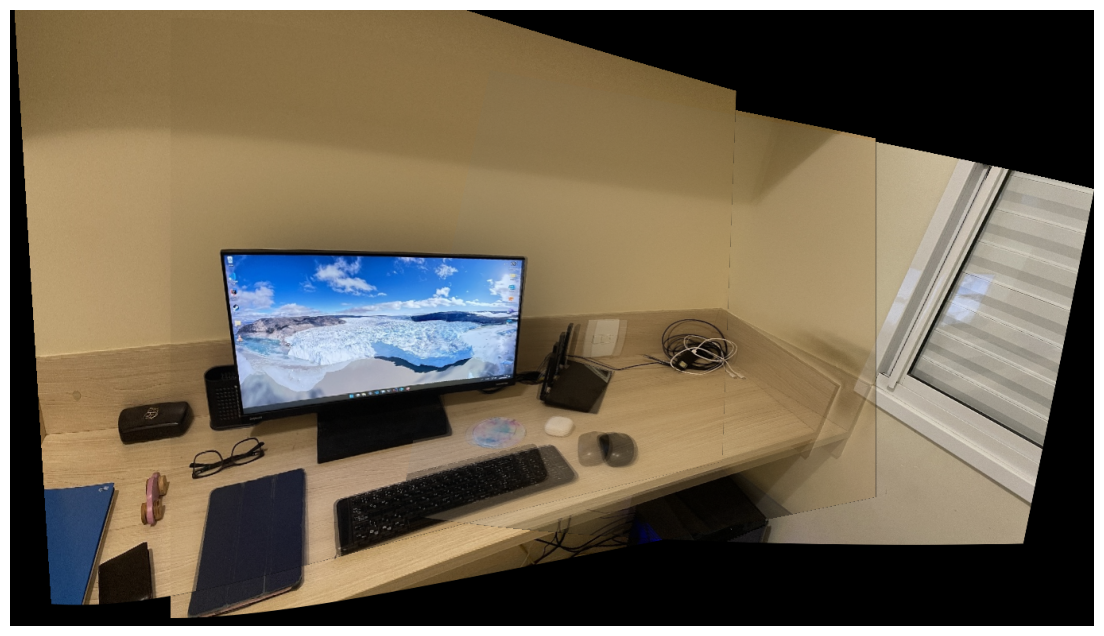

{'reference_position': 1, 'reference_index': 1, 'global_homographies': [array([[ 1.43139462e+00,  1.01920270e-01, -3.67447724e+02],
       [ 9.68505975e-02,  1.33340535e+00, -1.45565139e+02],
       [ 3.68418250e-04,  1.81135677e-04,  1.00000000e+00]]), array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), array([[ 4.36610648e-01, -1.07276927e-01,  3.59851901e+02],
       [-8.20938413e-03,  6.80384756e-01,  9.24308268e+00],
       [-2.67656889e-04,  3.67022989e-05,  7.78712931e-01]])], 'theta_min_degrees': np.float64(-49.267242170776925), 'theta_max_degrees': np.float64(54.88885853086509), 'y_min': np.float64(-386.5082561052884), 'y_max': np.float64(388.35876206067), 'canvas_width': 1364, 'canvas_height': 775}


In [4]:
from src.features import draw_keypoints
from src.matching import match_all_images
from src.homography import estimate_all_homographies
from src.visualization import plot_image
from src.composition import cylindrical_stitching

images_sift = draw_keypoints([image1, image2, image3])
matches_matrix, lowe_matrix = match_all_images([item["descriptors"] for item in images_sift], method="sift", ratio=0.7)
homographies, homography_metrics = estimate_all_homographies(lowe_matrix, [item["keypoints"] for item in images_sift], [0, 1, 2])

panorama, info = cylindrical_stitching([image1, image2, image3], [0, 1, 2], homographies, 750)
print(homography_metrics)

plot_image(panorama)
print(info)